In [1]:
# Project Scenario: Smart Waste Classification System
# A city municipality wants to build an AI-powered waste segregation system that can automatically classify images of waste into:

# Recyclable Waste

# Organic Waste

# Non-Recyclable Waste

# You are required to build a deep learning image classifier that can perform this task.

# Task 1 – Dataset Collection (5 Marks)
# Download or collect a dataset of waste images from sources 

# https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification?utm_source=chatgpt.com


# Organize the dataset into the following folder structure:

# dataset/

#    train/

#        recyclable/

#        organic/

#        non_recyclable/


#    validation/

#        recyclable/

#        organic/

#        non_recyclable/


# Deliverable:
# • Show the dataset structure and total number of images in each class.

# Task 2 – Data Preprocessing (5 Marks)
# Perform the following preprocessing steps:

# Resize images to a fixed size (e.g., 224×224)

# Normalize pixel values

# Apply data augmentation (at least 3 techniques)

# Examples:

# Rotation

# Horizontal flip

# Zoom

# Brightness adjustment

# Deliverable:
# • Show the preprocessing pipeline code.

# Task 3 – CNN Model Development (8 Marks)
# Build an image classification model using CNN.

# Your model should include:

# Convolution layers

# Pooling layers

# Dense layers

# Softmax output layer

# Train the model and display:

# Training accuracy

# Validation accuracy

# Training loss curve

# Deliverable:

# • Model architecture
# • Training output
# • Accuracy graph

# Task 4 – Model Evaluation (6 Marks)
# Evaluate the trained model using:

# Confusion Matrix

# Accuracy score

# Sample predictions on test images

# Deliverable:

# • Confusion matrix visualization
# • 5 test image predictions with predicted labels

# Task 5 – Transfer Learning Implementation (6 Marks)
# Improve your system by implementing Transfer Learning using a pretrained model such as:

# ResNet50

# MobileNetV2

# VGG16

# Steps:

# Load a pretrained model

# Freeze base layers

# Add custom classification layers

# Train the model

# Compare results with your original CNN model.

# Deliverable:

# • Accuracy comparison between Custom CNN vs Transfer Learning model

In [2]:
import os

dataset_path = "dataset"

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")

dataset/
    train/
        Non-Recylable/
        Organic/
        Recyclable/
    validation/
        Non-Recyclable/
        Organic/
        Recyclable/


In [3]:
train_path = "dataset/train"
val_path = "dataset/validation"

print("TRAIN DATASET")
for folder in os.listdir(train_path):
    folder_path = os.path.join(train_path, folder)
    print(folder, ":", len(os.listdir(folder_path)), "images")

print("\nVALIDATION DATASET")
for folder in os.listdir(val_path):
    folder_path = os.path.join(val_path, folder)
    print(folder, ":", len(os.listdir(folder_path)), "images")

TRAIN DATASET
Non-Recylable : 104 images
Organic : 804 images
Recyclable : 1115 images

VALIDATION DATASET
Non-Recyclable : 33 images
Organic : 193 images
Recyclable : 278 images


In [4]:
# Task 2 – Data Preprocessing Pipeline Code

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Training data generator with augmentation
train_datagen = ImageDataGenerator(
    
    rescale=1./255,              # Normalize pixel values (0–1)
    
    rotation_range=30,           # Random rotation
    
    horizontal_flip=True,        # Flip images horizontally
    
    zoom_range=0.2,              # Zoom augmentation
    
    brightness_range=[0.8,1.2]   # Brightness adjustment
    
)

# Validation data generator (only normalization)
validation_datagen = ImageDataGenerator(
    rescale=1./255
)

# Load training dataset
train_generator = train_datagen.flow_from_directory(
    
    "dataset/train",
    
    target_size=(224,224),   # Resize images to 224x224
    
    batch_size=32,
    
    class_mode='categorical'
)

# Load validation dataset
validation_generator = validation_datagen.flow_from_directory(
    
    "dataset/validation",
    
    target_size=(224,224),   # Resize images
    
    batch_size=32,
    
    class_mode='categorical'
)

Found 2023 images belonging to 3 classes.
Found 504 images belonging to 3 classes.


In [6]:
# Task 3 – CNN Model Development

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt
model = Sequential([

    # Convolution Layer 1
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(pool_size=(2,2)),

    # Convolution Layer 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    # Convolution Layer 3
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    # Flatten layer
    Flatten(),

    # Dense Layer
    Dense(128, activation='relu'),
    Dropout(0.5),

    # Output Layer (3 Classes)
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\admin\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.5917 - loss: 0.8747 - val_accuracy: 0.6825 - val_loss: 0.6702
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.6911 - loss: 0.6686 - val_accuracy: 0.7004 - val_loss: 0.6323
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.6970 - loss: 0.6756 - val_accuracy: 0.6488 - val_loss: 0.6683
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.6920 - loss: 0.6803 - val_accuracy: 0.7123 - val_loss: 0.6396
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.7143 - loss: 0.6371 - val_accuracy: 0.7103 - val_loss: 0.6050
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.7192 - loss: 0.6035 - val_accuracy: 0.7044 - val_loss: 0.5859
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.7039 - loss: 0.6277 - val_accuracy: 0.6925 - val_loss: 0.5796
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.7341 - loss: 0.5793 - val_accuracy: 0.7302 - val_loss:

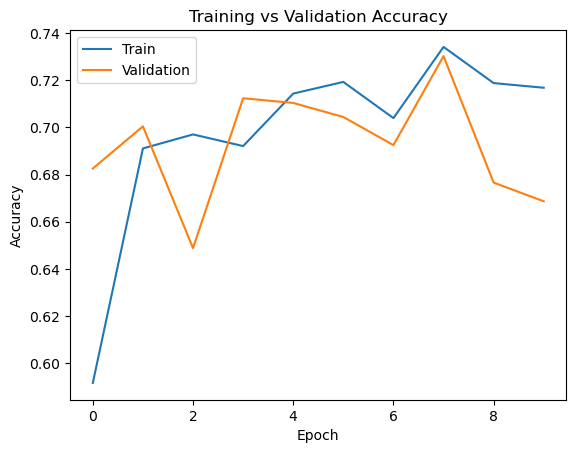

In [9]:
plt.figure()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

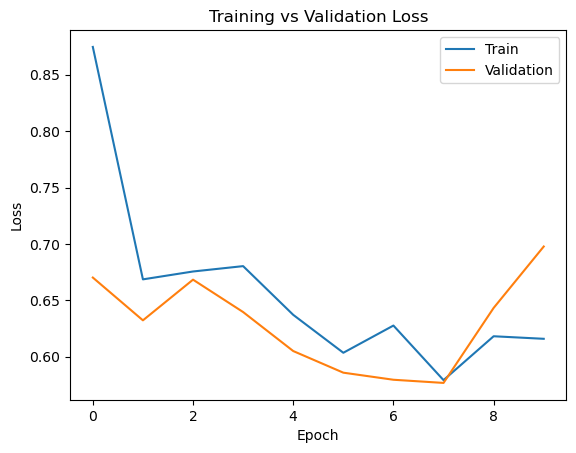

In [10]:
plt.figure()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [11]:
# Task 4 – Model Evaluation

In [12]:
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Predict classes for validation data
predictions = model.predict(validation_generator)

# Convert probabilities to class labels
y_pred = np.argmax(predictions, axis=1)

# True labels
y_true = validation_generator.classes

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 215ms/step


In [13]:
accuracy = accuracy_score(y_true, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.48214285714285715


In [14]:
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[  0  18  15]
 [  1  90 102]
 [  0 125 153]]


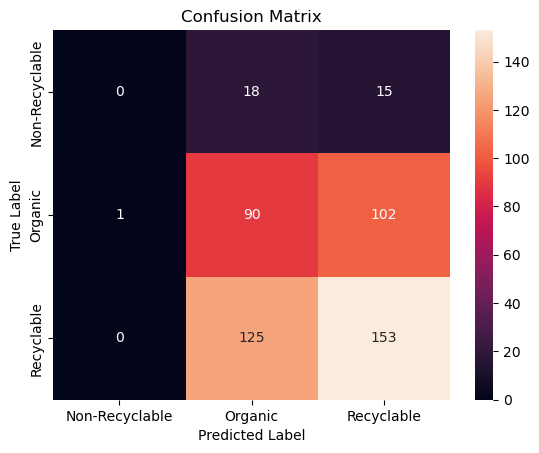

In [15]:
plt.figure()

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=validation_generator.class_indices.keys(),
    yticklabels=validation_generator.class_indices.keys()
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [16]:
print(train_generator.class_indices)

{'Non-Recylable': 0, 'Organic': 1, 'Recyclable': 2}


In [17]:
from tensorflow.keras.preprocessing import image
import os

class_names = list(train_generator.class_indices.keys())

test_folder = "dataset/validation/Organic/"

files = os.listdir(test_folder)[:5]

for file in files:

    img_path = os.path.join(test_folder, file)

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)/255
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    predicted_class = class_names[np.argmax(prediction)]

    print("Image:", file)
    print("Predicted Label:", predicted_class)
    print()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
Image: cardboard325.jpg
Predicted Label: Organic

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Image: cardboard326.jpg
Predicted Label: Organic

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Image: cardboard327.jpg
Predicted Label: Organic

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Image: cardboard328.jpg
Predicted Label: Organic

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Image: cardboard329.jpg
Predicted Label: Organic



In [18]:
# Task 5 – Transfer Learning Implementation

In [19]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

In [20]:
for layer in base_model.layers:
    layer.trainable = False

In [21]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation="relu")(x)

output = Dense(train_generator.num_classes, activation="softmax")(x)

model_transfer = Model(inputs=base_model.input, outputs=output)

In [22]:
model_transfer.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_transfer.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [23]:
history_transfer = model_transfer.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5
)

Epoch 1/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.8917 - loss: 0.3251 - val_accuracy: 0.8849 - val_loss: 0.4127
Epoch 2/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.9397 - loss: 0.1863 - val_accuracy: 0.8710 - val_loss: 0.3973
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.9481 - loss: 0.1422 - val_accuracy: 0.8651 - val_loss: 0.3848
Epoch 4/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 268s 4s/step - accuracy: 0.9595 - loss: 0.1238 - val_accuracy: 0.8849 - val_loss: 0.3870
Epoch 5/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.9674 - loss: 0.0980 - val_accuracy: 0.8810 - val_loss: 0.4041


In [24]:
cnn_accuracy = history.history["val_accuracy"][-1]
transfer_accuracy = history_transfer.history["val_accuracy"][-1]

print("Custom CNN Accuracy:", cnn_accuracy)
print("Transfer Learning Accuracy:", transfer_accuracy)

Custom CNN Accuracy: 0.6686508059501648
Transfer Learning Accuracy: 0.8809523582458496
